In [2]:
!pip install neo4j langchain langchain-community sentence-transformers pandas matplotlib

In [3]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [4]:
!pip install neo4j langchain langchain-community sentence-transformers pandas matplotlib openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.3 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [5]:
import neo4j
import langchain
import pandas
from sentence_transformers import SentenceTransformer

print("All libraries loaded successfully")

All libraries loaded successfully


In [7]:
# from neo4j import GraphDatabase

# URI = "neo4j+s://027fad4f.databases.neo4j.io"
# USERNAME = "0f1d0d3a"        # usually neo4j
# PASSWORD = "yd4xj7ZwTuPsYqJJWDMTJyO0kDl_c71_yXuU3IU1aDc"  # replace this
# # USERNAME = "neo4j"
# # PASSWORD = "HiSona23"

# driver = GraphDatabase.driver(URI, auth=(USERNAME, PASSWORD))

# with driver.session() as session:
#     result = session.run("RETURN 'Connected to Neo4j 🚀' AS msg")
#     print(result.single()["msg"])

from neo4j import GraphDatabase

URI = "neo4j+s://0f1d0d3a.databases.neo4j.io"
AUTH = ("0f1d0d3a", "yd4xj7ZwTuPsYqJJWDMTJyO0kDl_c71_yXuU3IU1aDc")

with GraphDatabase.driver(URI, auth=AUTH) as driver:
    driver.verify_connectivity()
    print("Connected to Neo4j ")

Connected to Neo4j 


In [8]:
from neo4j import GraphDatabase

URI = "neo4j+s://0f1d0d3a.databases.neo4j.io"
AUTH = ("0f1d0d3a", "yd4xj7ZwTuPsYqJJWDMTJyO0kDl_c71_yXuU3IU1aDc")

driver = GraphDatabase.driver(URI, auth=AUTH)

with driver.session() as session:
    session.run("""
    CREATE CONSTRAINT IF NOT EXISTS
    FOR (c:Customer)
    REQUIRE c.customer_id IS UNIQUE
    """)

    session.run("""
    CREATE CONSTRAINT IF NOT EXISTS
    FOR (p:Product)
    REQUIRE p.product_id IS UNIQUE
    """)

    session.run("""
    CREATE CONSTRAINT IF NOT EXISTS
    FOR (t:Transaction)
    REQUIRE t.transaction_id IS UNIQUE
    """)

print("Constraints created ")

Constraints created 


In [9]:
with driver.session() as session:
    session.run("""
    CREATE (c:Customer {customer_id: 1, name: 'Sona', age: 22})
    CREATE (p:Product {product_id: 101, name: 'Laptop', category: 'Electronics'})
    CREATE (t:Transaction {transaction_id: 1001, amount: 75000})

    CREATE (c)-[:PURCHASED]->(t)
    CREATE (t)-[:CONTAINS]->(p)
    """)

print("Sample graph created ")

Sample graph created 


In [10]:
with driver.session() as session:
    result = session.run("MATCH (n) RETURN n LIMIT 10")
    for record in result:
        print(record)

<Record n=<Node element_id='4:1ce494b0-e9e8-416f-87cc-47afa833a336:0' labels=frozenset({'Product'}) properties={'product_name': 'Nintendo Switch', 'product_category': 'Gaming Consoles'}>>
<Record n=<Node element_id='4:1ce494b0-e9e8-416f-87cc-47afa833a336:1' labels=frozenset({'Product'}) properties={'product_name': 'Table Lamp', 'product_category': 'Home Decor'}>>
<Record n=<Node element_id='4:1ce494b0-e9e8-416f-87cc-47afa833a336:2' labels=frozenset({'Product'}) properties={'product_name': 'Philips Hue Lights', 'product_category': 'Smart Home Devices'}>>
<Record n=<Node element_id='4:1ce494b0-e9e8-416f-87cc-47afa833a336:3' labels=frozenset({'Customer'}) properties={'full_name': 'Mark Johnson', 'gender': 'Male', 'city': 'Houston', 'state': 'Texas', 'customer_id': '4c30e132-0704-4459-a509-9eddde934977', 'age': 40.0, 'email': 'mark.johnson@yahoo.com', 'preferred_channel': nan}>>
<Record n=<Node element_id='4:1ce494b0-e9e8-416f-87cc-47afa833a336:4' labels=frozenset({'Customer'}) properties=

In [11]:
from google.colab import files
uploaded = files.upload()



Saving campaigns.csv to campaigns.csv
Saving customer_reviews_complete.csv to customer_reviews_complete.csv
Saving customers.csv to customers.csv
Saving interactions.csv to interactions.csv
Saving support_tickets.csv to support_tickets.csv
Saving transactions.csv to transactions.csv


In [12]:
!ls

campaigns.csv		       interactions.csv     transactions.csv
customer_reviews_complete.csv  sample_data
customers.csv		       support_tickets.csv


In [13]:
import pandas as pd

customers = pd.read_csv("customers.csv")
transactions = pd.read_csv("transactions.csv")
interactions = pd.read_csv("interactions.csv")
campaigns = pd.read_csv("campaigns.csv")
reviews = pd.read_csv("customer_reviews_complete.csv")
tickets = pd.read_csv("support_tickets.csv")

print("Customers:", customers.shape)
print("Transactions:", transactions.shape)
print("Interactions:", interactions.shape)
print("Campaigns:", campaigns.shape)
print("Reviews:", reviews.shape)
print("Support Tickets:", tickets.shape)

Customers: (5000, 12)
Transactions: (32295, 10)
Interactions: (100000, 8)
Campaigns: (200, 12)
Reviews: (1000, 10)
Support Tickets: (3000, 10)


In [20]:
customers.head()

,customer_id,full_name,age,gender,email,phone,street_address,city,state,zip_code,registration_date,preferred_channel
0,4c30e132-0704-4459-a509-9eddde934977,Mark Johnson,40.0,Male,mark.johnson@yahoo.com,989.608.3863,819 Johnson Course,Houston,Texas,29158.0,2024-04-25,NaN
1,68bec407-275f-4b5b-9a82-13d02f54626a,Robert Smith,33.0,Male,smithr@yahoo.com,(518)349-5931x0341,35116 Michael Key Suite 078,Austin,Texas,16862.0,2021-05-30,in-store
2,4466459f-76c8-433c-814e-6d59cb4131fc,Jamie Chavez,42.0,Female,jchavez@gmail.com,364.583.5030x564,419 Amanda Gardens,Detroit,Michigan,21918.0,2023-12-14,online
3,04c36a25-02f3-462c-92b0-6bf291c57706,Thomas Bradley,53.0,Male,thomas.bradley@hotmail.com,(332)887-1012x269,7242 Julie Plain Suite 969,Fort Worth,Texas,52851.0,2022-07-11,both
4,e916df3d-c3f5-40b0-8ae2-5d043be88300,Jane Ferrell,32.0,Female,jane.ferrell@hotmail.com,5484281489,845 Kelly Estate,Atlanta,Georgia,59971.0,2020-09-06,online


In [14]:
transactions.columns

Index(['transaction_id', 'customer_id', 'product_name', 'product_category',
       'quantity', 'price', 'transaction_date', 'store_location',
       'payment_method', 'discount_applied'],
      dtype='object')

In [16]:
# Convert numeric fields properly
transactions["price"] = pd.to_numeric(transactions["price"], errors="coerce")
transactions["quantity"] = pd.to_numeric(transactions["quantity"], errors="coerce")

# Fill missing product names
transactions["product_name"] = transactions["product_name"].fillna("Unknown")

# Convert date column
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"], errors="coerce"
)

print("Cleaning done successfully")

Cleaning done successfully


In [17]:
customers.columns

Index(['customer_id', 'full_name', 'age', 'gender', 'email', 'phone',
       'street_address', 'city', 'state', 'zip_code', 'registration_date',
       'preferred_channel'],
      dtype='object')

In [18]:
# Convert date column
customers["registration_date"] = pd.to_datetime(
    customers["registration_date"], errors="coerce"
)

# Ensure age is numeric
customers["age"] = pd.to_numeric(customers["age"], errors="coerce")

print("Customer cleaning done")

Customer cleaning done


In [19]:
with driver.session() as session:
    session.run("MATCH (n) DETACH DELETE n")

print("Database cleared")

Database cleared


In [20]:
with driver.session() as session:
    session.run("""
    CREATE CONSTRAINT IF NOT EXISTS
    FOR (c:Customer)
    REQUIRE c.customer_id IS UNIQUE
    """)

    session.run("""
    CREATE CONSTRAINT IF NOT EXISTS
    FOR (t:Transaction)
    REQUIRE t.transaction_id IS UNIQUE
    """)

print("Constraints created")

Constraints created


In [21]:
customer_data = customers.to_dict("records")

with driver.session() as session:
    session.run("""
    UNWIND $customers AS c
    CREATE (:Customer {
        customer_id: c.customer_id,
        full_name: c.full_name,
        age: c.age,
        gender: c.gender,
        email: c.email,
        city: c.city,
        state: c.state,
        preferred_channel: c.preferred_channel
    })
    """, customers=customer_data)

print("Customers loaded into Neo4j")

Customers loaded into Neo4j


In [22]:
with driver.session() as session:
    result = session.run("MATCH (c:Customer) RETURN COUNT(c) AS count")
    print("Customer count in Neo4j:", result.single()["count"])

Customer count in Neo4j: 5000


In [23]:
transaction_data = transactions.to_dict("records")

In [24]:
batch_size = 1000

for i in range(0, len(transaction_data), batch_size):
    batch = transaction_data[i:i+batch_size]

    with driver.session() as session:
        session.run("""
        UNWIND $transactions AS t

        MATCH (c:Customer {customer_id: t.customer_id})

        CREATE (tr:Transaction {
            transaction_id: t.transaction_id,
            product_name: t.product_name,
            product_category: t.product_category,
            quantity: t.quantity,
            price: t.price,
            transaction_date: t.transaction_date,
            store_location: t.store_location,
            payment_method: t.payment_method,
            discount_applied: t.discount_applied
        })

        CREATE (c)-[:PURCHASED]->(tr)
        """, transactions=batch)

    print(f"Loaded batch {i//batch_size + 1}")

Loaded batch 1
Loaded batch 2
Loaded batch 3
Loaded batch 4
Loaded batch 5
Loaded batch 6
Loaded batch 7
Loaded batch 8
Loaded batch 9
Loaded batch 10
Loaded batch 11
Loaded batch 12
Loaded batch 13
Loaded batch 14
Loaded batch 15
Loaded batch 16
Loaded batch 17
Loaded batch 18
Loaded batch 19
Loaded batch 20
Loaded batch 21
Loaded batch 22
Loaded batch 23
Loaded batch 24
Loaded batch 25
Loaded batch 26
Loaded batch 27
Loaded batch 28
Loaded batch 29
Loaded batch 30
Loaded batch 31
Loaded batch 32
Loaded batch 33


In [25]:
with driver.session() as session:
    result = session.run("MATCH (t:Transaction) RETURN COUNT(t) AS count")
    print("Transaction count in Neo4j:", result.single()["count"])

Transaction count in Neo4j: 32295


In [27]:
# Clean product data
unique_products = transactions[["product_name", "product_category"]].drop_duplicates()

# Replace NaN values
unique_products["product_name"] = unique_products["product_name"].fillna("Unknown Product")
unique_products["product_category"] = unique_products["product_category"].fillna("Unknown Category")

product_data = unique_products.to_dict("records")

print("Product data cleaned ")

Product data cleaned 


In [30]:
with driver.session() as session:
    session.run("""
    UNWIND $products AS p
    MERGE (:Product {
        product_name: p.product_name,
        product_category: p.product_category
    })
    """, products=product_data)

print("Product nodes created successfully")

Product nodes created successfully


<Axes: >

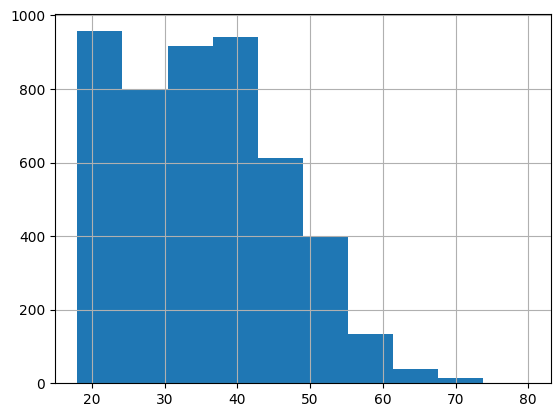

In [31]:
customers['age'].hist()

In [33]:
reviews['rating'].value_counts()

,count
rating,
5,402
4,350
3,142
2,76
1,30


In [34]:
with driver.session() as session:
    session.run("""
    MATCH (t:Transaction)
    MATCH (p:Product {product_name: t.product_name})
    MERGE (t)-[:CONTAINS]->(p)
    """)

print("Transactions linked to Products")

Transactions linked to Products


In [35]:
with driver.session() as session:
    result = session.run("MATCH (p:Product) RETURN COUNT(p) AS count")
    print("Product count:", result.single()["count"])

with driver.session() as session:
    result = session.run("MATCH ()-[r:CONTAINS]->() RETURN COUNT(r) AS count")
    print("CONTAINS relationships:", result.single()["count"])

Product count: 165
CONTAINS relationships: 73949


In [36]:
reviews.columns

Index(['review_id', 'customer_id', 'product_name', 'product_category',
       'full_name', 'transaction_date', 'review_date', 'rating',
       'review_title', 'review_text'],
      dtype='object')

In [45]:
reviews.head()

,review_id,customer_id,product_name,product_category,full_name,transaction_date,review_date,rating,review_title,review_text
0,rev_000001,e9848049-323f-4f95-a26e-3cffc219d591,Bookshelf,Furniture,Patrick Guerrero,2024-05-30,2024-06-12,5,Sturdy and Elegant Addition to My Study Room,Just received the bookshelf I've been eyeing f...
1,rev_000002,24bcc3c6-ce17-423f-87f5-a1f6d1114ba7,Oculus Quest,Gaming Consoles,Katie Burton,2024-03-10,2024-04-05,5,Immersive Virtual Reality Adventure!,"Katie Burton, a tech enthusiast from Dallas, T..."
2,rev_000003,8806399f-1c9b-47f7-b8ca-fac5468438ff,OnePlus 10,Smartphones,Fernando Rogers,2024-06-14,2024-06-29,4,"Impressive Performance, Room for Improvement i...",The OnePlus 10 has been a great addition to my...
3,rev_000004,62ab496d-f69a-48af-b44c-08ac79b6f68d,iPhone 13,Smartphones,Sara Howell,2024-03-27,2024-04-06,4,"Solid Upgrade, Could've Been Perfect!",The iPhone 13 has been a great addition to my ...
4,rev_000005,1b7daed4-aaa6-41b1-9826-0d51d67614e3,Bookshelf,Furniture,Kelly Kim,2023-08-16,2023-09-01,4,"Sturdy, Yet Lacking Personality",I recently purchased this bookshelf for my hom...


In [37]:
reviews["product_name"] = reviews["product_name"].fillna("Unknown Product")
reviews["product_category"] = reviews["product_category"].fillna("Unknown Category")
reviews["review_text"] = reviews["review_text"].fillna("No review text")

reviews["rating"] = pd.to_numeric(reviews["rating"], errors="coerce")
reviews["review_date"] = pd.to_datetime(reviews["review_date"], errors="coerce")

print("Review cleaning done")

Review cleaning done


In [38]:
review_data = reviews.to_dict("records")

batch_size = 500

for i in range(0, len(review_data), batch_size):
    batch = review_data[i:i+batch_size]

    with driver.session() as session:
        session.run("""
        UNWIND $reviews AS r

        MATCH (c:Customer {customer_id: r.customer_id})
        MATCH (p:Product {product_name: r.product_name})

        CREATE (rev:Review {
            review_id: r.review_id,
            rating: r.rating,
            review_title: r.review_title,
            review_text: r.review_text,
            review_date: r.review_date
        })

        CREATE (c)-[:WROTE]->(rev)
        CREATE (rev)-[:ABOUT]->(p)
        """, reviews=batch)

    print(f"Loaded review batch {i//batch_size + 1}")

print("All reviews loaded")

Loaded review batch 1
Loaded review batch 2
All reviews loaded


In [39]:
with driver.session() as session:
    result = session.run("MATCH (r:Review) RETURN COUNT(r) AS count")
    print("Review count:", result.single()["count"])

with driver.session() as session:
    result = session.run("MATCH ()-[r:WROTE]->() RETURN COUNT(r) AS count")
    print("WROTE relationships:", result.single()["count"])

Review count: 1952
WROTE relationships: 1952


In [40]:
reviews.shape

(1000, 10)

In [41]:
with driver.session() as session:
    session.run("MATCH (r:Review) DETACH DELETE r")

print("Old review nodes deleted")

Old review nodes deleted


In [42]:
review_data = reviews.to_dict("records")

batch_size = 500

for i in range(0, len(review_data), batch_size):
    batch = review_data[i:i+batch_size]

    with driver.session() as session:
        session.run("""
        UNWIND $reviews AS r

        MATCH (c:Customer {customer_id: r.customer_id})
        MATCH (p:Product {product_name: r.product_name})

        MERGE (rev:Review {review_id: r.review_id})
        SET rev.rating = r.rating,
            rev.review_title = r.review_title,
            rev.review_text = r.review_text,
            rev.review_date = r.review_date

        MERGE (c)-[:WROTE]->(rev)
        MERGE (rev)-[:ABOUT]->(p)
        """, reviews=batch)

    print(f"Loaded review batch {i//batch_size + 1}")

print("Reviews reloaded cleanly")

Loaded review batch 1
Loaded review batch 2
Reviews reloaded cleanly


In [43]:
with driver.session() as session:
    result = session.run("MATCH (r:Review) RETURN COUNT(r) AS count")
    print("Review count:", result.single()["count"])

Review count: 976


In [44]:
review_customer_ids = set(reviews["customer_id"])
customer_ids = set(customers["customer_id"])

missing_customers = review_customer_ids - customer_ids
print("Missing customers count:", len(missing_customers))

Missing customers count: 0


In [45]:
transactions["product_name"]

,product_name
0,Ring Doorbell
1,Oculus Quest
2,Samsung Galaxy S22
3,External Hard Drive
4,MacBook Pro
...,...
32290,Wall Art
32291,Sony Soundbar
32292,Bookshelf
32293,Table Lamp


In [46]:
review_products = set(reviews["product_name"].unique())
transaction_products = set(transactions["product_name"].unique())

missing_products = review_products - transaction_products

print("Missing products count:", len(missing_products))
print("Missing products:", missing_products)

Missing products count: 1
Missing products: {'Unknown Product'}


In [48]:
with driver.session() as session:
    session.run("""
    MERGE (:Product {
        product_name: 'Unknown Product',
        product_category: 'Unknown Category'
    })
    """)

print("Unknown Product node created")

Unknown Product node created


In [49]:
with driver.session() as session:
    session.run("MATCH (r:Review) DETACH DELETE r")

In [50]:
with driver.session() as session:
    result = session.run("MATCH (r:Review) RETURN COUNT(r) AS count")
    print("Review count:", result.single()["count"])

Review count: 0


In [52]:
review_data = reviews.to_dict("records")

batch_size = 500

for i in range(0, len(review_data), batch_size):
    batch = review_data[i:i+batch_size]

    with driver.session() as session:
        session.run("""
        UNWIND $reviews AS r

        MATCH (c:Customer {customer_id: r.customer_id})
        MATCH (p:Product {product_name: r.product_name})

        MERGE (rev:Review {review_id: r.review_id})
        SET rev.rating = r.rating,
            rev.review_title = r.review_title,
            rev.review_text = r.review_text,
            rev.review_date = r.review_date

        MERGE (c)-[:WROTE]->(rev)
        MERGE (rev)-[:ABOUT]->(p)
        """, reviews=batch)

    print(f"Loaded review batch {i//batch_size + 1}")

print("Reviews reloaded cleanly")

Loaded review batch 1
Loaded review batch 2
Reviews reloaded cleanly


In [53]:
with driver.session() as session:
    result = session.run("MATCH (r:Review) RETURN COUNT(r) AS count")
    print("Review count:", result.single()["count"])

Review count: 1000


In [54]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded


In [55]:
review_texts = reviews["review_text"].tolist()

embeddings = model.encode(review_texts, show_progress_bar=True)

print("Embeddings generated:", len(embeddings))

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embeddings generated: 1000


In [56]:
len(embeddings[0])

384

In [58]:
review_ids = reviews["review_id"].tolist()

batch_size = 200

for i in range(0, len(review_ids), batch_size):
    batch_ids = review_ids[i:i+batch_size]
    batch_embeddings = embeddings[i:i+batch_size]

    payload = [
        {"review_id": rid, "embedding": emb.tolist()}
        for rid, emb in zip(batch_ids, batch_embeddings)
    ]

    with driver.session() as session:
        session.run("""
        UNWIND $rows AS row
        MATCH (r:Review {review_id: row.review_id})
        SET r.embedding = row.embedding
        """, rows=payload)

    print(f"Stored embedding batch {i//batch_size + 1}")

print("All embeddings stored in Neo4j")

Stored embedding batch 1
Stored embedding batch 2
Stored embedding batch 3
Stored embedding batch 4
Stored embedding batch 5
All embeddings stored in Neo4j


In [59]:
with driver.session() as session:
    session.run("""
    CREATE VECTOR INDEX review_embedding_index IF NOT EXISTS
    FOR (r:Review)
    ON (r.embedding)
    OPTIONS {
        indexConfig: {
            `vector.dimensions`: 384,
            `vector.similarity_function`: 'cosine'
        }
    }
    """)

print("Vector index created")

Vector index created


In [60]:
query_text = "Great product quality and durability"

query_embedding = model.encode(query_text).tolist()

with driver.session() as session:
    result = session.run("""
    CALL db.index.vector.queryNodes(
        'review_embedding_index',
        5,
        $embedding
    )
    YIELD node, score
    RETURN node.review_title AS title,
           node.rating AS rating,
           score
    """, embedding=query_embedding)

    for record in result:
        print(record)

<Record title='Stunning Wall Art for a Modest Price!' rating=4 score=0.7584097385406494>
<Record title='Perfect Fit for Our Living Room!' rating=5 score=0.7487533092498779>
<Record title='A Gorgeous Addition to My Living Space!' rating=5 score=0.742011547088623>
<Record title='Disappointed with the Delivery and Quality of the Wall Art' rating=2 score=0.7380316257476807>
<Record title='Perfectly Sturdy and Aesthetic Bed Frame!' rating=5 score=0.7365589141845703>


In [61]:
query_text = "Durable furniture with good quality"

query_embedding = model.encode(query_text).tolist()

with driver.session() as session:
    result = session.run("""
    CALL db.index.vector.queryNodes(
        'review_embedding_index',
        3,
        $embedding
    )
    YIELD node AS review, score

    MATCH (review)-[:ABOUT]->(p:Product)
    MATCH (review)<-[:WROTE]-(c:Customer)

    RETURN
        review.review_title AS review_title,
        p.product_name AS product,
        c.full_name AS customer,
        score
    """, embedding=query_embedding)

    for record in result:
        print(record)

<Record review_title='Perfect Fit for Our Living Room!' product='Sofa' customer='David Roberts' score=0.8272659778594971>
<Record review_title='Perfect Fit for Our Living Room!' product='Sofa' customer='David Roberts' score=0.8272659778594971>
<Record review_title='Perfectly Sturdy and Aesthetic Bed Frame!' product='Bed Frame' customer='Katherine Guerrero' score=0.8142251968383789>
<Record review_title='Perfectly Sturdy and Aesthetic Bed Frame!' product='Bed Frame' customer='Katherine Guerrero' score=0.8142251968383789>
<Record review_title='Disappointed with the Quality of This Sofa' product='Sofa' customer='Melissa Martinez' score=0.800976037979126>
<Record review_title='Disappointed with the Quality of This Sofa' product='Sofa' customer='Melissa Martinez' score=0.800976037979126>


In [62]:
with driver.session() as session:
    result = session.run("""
    MATCH (r:Review)
    RETURN r.review_id, COUNT {
        MATCH (r)<-[:WROTE]-(:Customer)
    } AS wrote_count,
    COUNT {
        MATCH (r)-[:ABOUT]->(:Product)
    } AS about_count
    LIMIT 5
    """)

    for record in result:
        print(record)

<Record r.review_id='rev_000001' wrote_count=1 about_count=2>
<Record r.review_id='rev_000002' wrote_count=1 about_count=2>
<Record r.review_id='rev_000003' wrote_count=1 about_count=2>
<Record r.review_id='rev_000004' wrote_count=1 about_count=2>
<Record r.review_id='rev_000005' wrote_count=1 about_count=2>


In [63]:
query_text = "Durable furniture with good quality"
query_embedding = model.encode(query_text).tolist()

with driver.session() as session:
    result = session.run("""
    CALL db.index.vector.queryNodes(
        'review_embedding_index',
        3,
        $embedding
    )
    YIELD node AS review, score

    MATCH (review)-[:ABOUT]->(p:Product)
    MATCH (review)<-[:WROTE]-(c:Customer)

    RETURN DISTINCT
        review.review_title AS review_title,
        p.product_name AS product,
        c.full_name AS customer,
        score
    """, embedding=query_embedding)

    for record in result:
        print(record)

<Record review_title='Perfect Fit for Our Living Room!' product='Sofa' customer='David Roberts' score=0.8272659778594971>
<Record review_title='Perfectly Sturdy and Aesthetic Bed Frame!' product='Bed Frame' customer='Katherine Guerrero' score=0.8142251968383789>
<Record review_title='Disappointed with the Quality of This Sofa' product='Sofa' customer='Melissa Martinez' score=0.800976037979126>


In [64]:
!pip install langchain openai

In [65]:


# import os
# from langchain.chat_models import ChatOpenAI

# os.environ["OPENAI_API_KEY"] = "sk-dafbbfb4f9134f609b2e5d8c3160c480"

# llm = ChatOpenAI(
#     model="deepseek-chat",
#     openai_api_base="https://api.deepseek.com",
#     temperature=0
# )

# print("DeepSeek connected ")

!pip install langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 1.7 MB/s eta 0:00:00


In [67]:
from langchain_openai import ChatOpenAI
import os

os.environ["OPENAI_API_KEY"] = "sk-dafbbfb4f9134f609b2e5d8c3160c480"

llm = ChatOpenAI(
    model="deepseek-chat",
    base_url="https://api.deepseek.com",
    temperature=0
)

print("DeepSeek connected ")

DeepSeek connected 


In [68]:
response = llm.invoke("Say hello in one sentence.")
print(response.content)

APIStatusError: Error code: 402 - {'error': {'message': 'Insufficient Balance', 'type': 'unknown_error', 'param': None, 'code': 'invalid_request_error'}}

In [69]:
def rule_based_cypher(question):
    q = question.lower()

    # Top spending customers
    if "top" in q and "spent" in q:
          return """
    MATCH (c:Customer)-[:PURCHASED]->(t:Transaction)
    WITH c, SUM(t.price * t.quantity) AS total_spent
    RETURN c.full_name AS customer,
           total_spent
    ORDER BY total_spent DESC
    LIMIT 5
    """
    # Top spending by category
    if "top" in q and "category" in q:
        category = q.split("category")[-1].strip().title()
        return f"""
        MATCH (c:Customer)-[:PURCHASED]->(t:Transaction)-[:CONTAINS]->(p:Product)
        WHERE p.product_category = '{category}'
        WITH c, SUM(t.price * t.quantity) AS total_spent
        RETURN c.full_name AS customer,
              total_spent
        ORDER BY total_spent DESC
        LIMIT 5
        """

    # Customers by state
    if "customers from" in q:
        state = q.split("from")[-1].strip().title()
        return f"""
        MATCH (c:Customer)
        WHERE c.state = '{state}'
        RETURN c.full_name AS customer, c.city AS city
        LIMIT 10
        """

    # High rating reviews
    if "rating 5" in q or "five star" in q:
          return """
    MATCH (c:Customer)-[:WROTE]->(r:Review)-[:ABOUT]->(p:Product)
    WHERE r.rating = 5
    RETURN DISTINCT
           c.full_name AS customer,
           p.product_name AS product,
           r.review_title AS review
    LIMIT 10
    """
    # Top rated products
    if "top rated products" in q:
        return """
        MATCH (r:Review)-[:ABOUT]->(p:Product)
        WITH p, AVG(r.rating) AS avg_rating
        RETURN p.product_name AS product,
              avg_rating
        ORDER BY avg_rating DESC
        LIMIT 5
        """
    # Product popularity
    if "most purchased products" in q:
        return """
        MATCH (t:Transaction)-[:CONTAINS]->(p:Product)
        RETURN p.product_name AS product,
               COUNT(*) AS purchase_count
        ORDER BY purchase_count DESC
        LIMIT 5
        """
      # Durable reviews from a state (Hybrid)
    # if "durable" in q and "from" in q:
    #     state = q.split("from")[-1].strip().title()
    #     return ("HYBRID", state)

    if any(word in q for word in ["durable", "quality", "best", "good", "excellent"]) and "from" in q:
        state = q.split("from")[-1].strip().title()
        return ("HYBRID", state)


    return None

In [70]:
def ask_graph(question):
    result = rule_based_cypher(question)

    if isinstance(result, tuple) and result[0] == "HYBRID":
        state = result[1]
        q = question.lower()

        # Detect category
        categories = ["furniture", "electronics", "smartphones", "gaming consoles", "appliances"]

        detected_category = None
        for cat in categories:
            if cat in q:
                detected_category = cat.title()
                break

        query_embedding = model.encode(question).tolist()

        with driver.session() as session:
          res = session.run("""
          CALL db.index.vector.queryNodes(
              'review_embedding_index',
              10,
              $embedding
          )
          YIELD node AS review, score

          MATCH (review)<-[:WROTE]-(c:Customer)
          MATCH (review)-[:ABOUT]->(p:Product)

          WHERE c.state = $state
          AND review.rating >= 4
          AND ($category IS NULL OR p.product_category = $category)

          RETURN DISTINCT
                review.review_title AS review,
                p.product_name AS product,
                c.full_name AS customer,
                score,
                review.rating AS rating
          ORDER BY score DESC
          LIMIT 5
          """,
          embedding=query_embedding,
          state=state,
          category=detected_category
          )

          return [r.data() for r in res]

    # normal rule-based
    if result:
        with driver.session() as session:
            res = session.run(result)
            return [r.data() for r in res]

    return "I don't understand the question yet."

In [71]:
ask_graph("Show durable furniture reviews from California")

[{'review': 'Perfect Fit for Our Living Room!',
  'product': 'Sofa',
  'customer': 'David Roberts',
  'score': 0.7468733787536621,
  'rating': 5},
 {'review': 'Absolutely Lovely Modern Sofa!',
  'product': 'Sofa',
  'customer': 'Tammy Marsh',
  'score': 0.7339658737182617,
  'rating': 5}]

In [72]:
with driver.session() as session:
    result = session.run("""
    MATCH (t:Transaction)
    RETURN t.price, t.quantity
    LIMIT 5
    """)

    for record in result:
        print(record)

<Record t.price=140.07 t.quantity=1.0>
<Record t.price=339.57 t.quantity=1.0>
<Record t.price=1335.88 t.quantity=2.0>
<Record t.price=91.56 t.quantity=1.0>
<Record t.price=985.15 t.quantity=1.0>


In [73]:
with driver.session() as session:
    result = session.run("""
    MATCH (t:Transaction)
    WHERE t.price IS NULL OR t.quantity IS NULL
    RETURN COUNT(t) AS null_count
    """)

    print(result.single()["null_count"])

0


In [74]:
ask_graph("Show top 5 customers who spent the most")

[{'customer': 'Jackson Ball', 'total_spent': nan},
 {'customer': 'Angel Flynn', 'total_spent': nan},
 {'customer': 'Chris Jones', 'total_spent': nan},
 {'customer': 'Lisa Perry', 'total_spent': nan},
 {'customer': 'Howard Norman', 'total_spent': nan}]

In [76]:
ask_graph("Find customers from California")

[{'customer': 'James Powers', 'city': 'San Francisco'},
 {'customer': 'Nicole Morgan', 'city': 'San Diego'},
 {'customer': 'Kevin Martin', 'city': 'San Diego'},
 {'customer': 'Susan Thompson', 'city': 'San Diego'},
 {'customer': 'Hannah Hill', 'city': 'San Diego'},
 {'customer': 'Robyn Dennis', 'city': 'Sacramento'},
 {'customer': 'Jacqueline Gutierrez', 'city': 'San Francisco'},
 {'customer': 'James Ford', 'city': 'Los Angeles'},
 {'customer': 'Sharon Crane', 'city': 'San Francisco'},
 {'customer': 'Robert Trujillo', 'city': 'San Jose'}]

In [77]:
ask_graph("Show five star reviews")

[{'customer': 'Patrick Guerrero',
  'product': 'Bookshelf',
  'review': 'Sturdy and Elegant Addition to My Study Room'},
 {'customer': 'Katie Burton',
  'product': 'Oculus Quest',
  'review': 'Immersive Virtual Reality Adventure!'},
 {'customer': 'Vernon Garrett',
  'product': 'Comforter Set',
  'review': 'Dreamy Slumber Achieved with This Comforter Set!'},
 {'customer': 'Troy Taylor',
  'product': 'Microsoft Surface',
  'review': 'Exceptional Workhorse for the Modern Creative Professional'},
 {'customer': 'Larry Young',
  'product': 'Range Hood',
  'review': 'Exceptional Range Hood Performance'},
 {'customer': 'Melissa Davis',
  'product': 'Refrigerator',
  'review': 'Incredible Efficiency and Sleek Design in my New Refrigerator!'},
 {'customer': 'Teresa Johnson',
  'product': 'Microwave Oven',
  'review': 'A Game Changer in My Kitchen!'},
 {'customer': 'Cheryl Gaines',
  'product': 'Sony Bravia',
  'review': 'Exceptional Viewing Experience with the Sony Bravia!'},
 {'customer': 'Anth